In [1]:
#导入必要的包
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
import os
import cv2
import numpy as np
import mediapipe as mp

In [2]:
# 创建一个字典，用于将每个标签(label)映射到对应的数字编号。
# 编号默认从 0 开始，这是很多机器学习任务中常见的做法（例如分类任务的类别编码）。

# 目标词语列表（将作为动作标签），替换成你自己的训练数据文件夹命名（已调整）
target_words = ["attention", "phone", "daydream", "sleepy"]

# 将目标词语转换为 NumPy 数组，便于后续处理
actions = np.array(target_words)

# 使用 enumerate 为每个标签分配一个从 0 开始递增的编号
# 生成的字典格式如：{"第一类上课状态": 0, "第二类": 1, "第三类": 2, ...}
label_map = {label: num for num, label in enumerate(actions)}

# 查看最终的标签映射字典
label_map



{'attention': 0, 'phone': 1, 'daydream': 2, 'sleepy': 3}

In [14]:
# 1. 彻底清空，防止重复运行导致数据堆叠
sequences = []
labels = []

# 2. 配置参数
no_of_sequences = 120  # 每个动作的视频数
sequence_length = 60   # 每个视频的帧数
DATA_PATH = os.path.join('data for different actions')

print("开始加载数据...")

for action in actions:
    for sequence in range(no_of_sequences):
        window = []
        
        # --- 只需要这一个循环即可 ---
        for frame_num in range(sequence_length):
            try:
                # 读取单帧数据
                file_path = os.path.join(DATA_PATH, action, str(sequence), "{}.npy".format(frame_num))
                res = np.load(file_path)
                
                # --- 极致降噪切片 (1662 -> 258) ---
                # 仅保留 Pose 和 Hands，剔除 Face
                res = np.concatenate([res[:132], res[1536:]]) 
                
                window.append(res)
            except FileNotFoundError:
                # 如果某个视频序列不完整，直接跳过这个 sequence
                break 
        
        # 3. 只有当这一组视频完整读够了 60 帧，才加入训练集
        if len(window) == sequence_length:
            sequences.append(window)
            labels.append(label_map[action])

# 4. 转换并验证形状
X = np.array(sequences)
y = to_categorical(labels).astype(int)

print(f"数据加载完成！")
print(f"X 的形状: {X.shape}") # 预期应该是 (总视频数, 60, 258)
print(f"y 的形状: {y.shape}")

开始加载数据...
数据加载完成！
X 的形状: (480, 60, 258)
y 的形状: (480, 4)


In [15]:
# 将所有视频序列（list of windows）转换为 NumPy 数组，以便送入深度学习模型
# 转换后 X 的形状应为：
# (总视频数量, sequence_length, 特征维度)
# 例如：(5, 30, 126)>>>(5个上课状态，每段视频有30帧的画面，有126个特征点)
X = np.array(sequences)

# 查看 X 的形状是否符合预期
X.shape


(480, 60, 258)

In [16]:
# 将原始标签（如 0, 1, 2, ...）转换为独热编码（One-Hot Encoding）
# 例如原始标签为：0 → [1,0,0],  1 → [0,1,0],  2 → [0,0,1]
# 这样做是因为深度学习模型（如分类模型）通常使用 one-hot 标签进行训练，
# 并且独热编码更适合用于计算 softmax + categorical crossentropy 损失。

y = to_categorical(labels).astype(int)

# 打印转换后的 y
# 如果有 5 个类别（不同的上课状态），输出每个标签会是一个长度为 5 的向量
y


array([[1, 0, 0, 0],
       [1, 0, 0, 0],
       [1, 0, 0, 0],
       ...,
       [0, 0, 0, 1],
       [0, 0, 0, 1],
       [0, 0, 0, 1]])

In [ ]:
# 将数据集划分为训练集（train）和测试集（test）
# test_size=0.05 表示：5% 的数据用于测试，95% 用于训练。
# 
# X 是形状为 (样本数, 帧数, 特征维度) 的 3D 数组，存放每段视频的关键点序列；
# y 是对应的 one-hot 标签。
#
# train_test_split 会自动将 X、y 按相同顺序拆分成训练集和测试集。

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.1, 
    stratify=y, # <--- 核心改动：分层抽样
    random_state=42
)



In [18]:
unique, counts = np.unique(np.argmax(y, axis=1), return_counts=True)
label_dist = dict(zip([actions[i] for i in unique], counts))

print("--- 全局数据分布 ---")
print(label_dist)

# 检查分完集后的分布
unique_test, counts_test = np.unique(np.argmax(y_test, axis=1), return_counts=True)
test_dist = dict(zip([actions[i] for i in unique_test], counts_test))

print("\n--- 测试集数据分布 ---")
print(test_dist)

--- 全局数据分布 ---
{'attention': 120, 'phone': 120, 'daydream': 120, 'sleepy': 120}

--- 测试集数据分布 ---
{'attention': 12, 'phone': 12, 'daydream': 12, 'sleepy': 12}


In [19]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import TensorBoard


In [20]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# 防止过拟合的早停器：如果 15 个 epoch 都没有进步，就停止训练并取最好的那次
early_stopping = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
# 自动调整学习率：如果模型卡住了，自动变聪明一点
lr_reducer = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)


In [21]:
# 创建日志文件夹（用于存放 TensorBoard 的训练日志）
# 训练过程中的损失（loss）、准确率（accuracy）等指标都会写入此目录
log_dir = os.path.join('train_Logs')

# TensorBoard 是 TensorFlow 自带的可视化工具，可以通过网页界面实时监控模型训练情况。
# 主要功能包括：
#   - 可视化 loss、accuracy 曲线
#   - 观察权重分布变化
#   - 评估过拟合情况
#   - 查看计算图（Graph）
#
# 下方语句创建一个 TensorBoard 回调函数，在 model.fit() 中使用即可自动记录训练日志。
tb_callback = TensorBoard(log_dir=log_dir)


In [ ]:
# ================================
# 构建用于动作分类的神经网络模型
# 使用 Keras Sequential API 逐层堆叠网络，结构简单清晰
# ================================

model = Sequential()

# -------------------------------
# 第 1 层 LSTM
# -------------------------------
# 参数说明：
#   64                → LSTM 单元数量（隐藏状态维度）
#   return_sequences=True → 必须为 True，因为后面还要堆叠 LSTM 层
#   activation='relu' → 使用 ReLU 激活函数
# relu炸了，改成用tanh
# input_shape=(60, 258)
#   表示每个样本的形状为 60 帧，每帧有 258 个关键点特征

# model.add(LSTM(64, return_sequences=True, activation='tanh', input_shape=(60, 1662)))
# 修改后（必须是 258）：
model.add(LSTM(64, return_sequences=True, activation='relu', input_shape=(60, 258)))
model.add(Dropout(0.3)) # 顺手加上这个，防止 1-0 乱跳
# -------------------------------
# 第 2 层 LSTM（继续返回序列）
# -------------------------------
# 128 单元，增强特征提取能力
model.add(LSTM(128, return_sequences=True, activation='tanh'))

# -------------------------------
# 第 3 层 LSTM
# -------------------------------
# return_sequences=False → 只输出最后一个时间步的输出（因为后面接 Dense 层）
model.add(LSTM(64, return_sequences=False, activation='tanh'))

# -------------------------------
# 全连接层（Dense Layers）
# -------------------------------
# 提取高层特征
model.add(Dense(64, activation='tanh'))
model.add(Dense(32, activation='tanh'))

# -------------------------------
# 输出层（分类层）
# -------------------------------
# actions.shape[0] 表示类别数，例如 5 个动作 → 输出维度为 5
# softmax 将输出转为概率分布（所有类别概率之和为 1）
model.add(Dense(actions.shape[0], activation='softmax'))



In [24]:
# ================================
# 模型编译（设置优化器、损失函数与评估指标）
# ================================

# optimizer='Adam'
#   Adam 是深度学习中常用且表现优秀的优化器，能够自动调整学习率，
#   在处理序列数据（如 LSTM）时表现稳定，收敛速度快。

# loss='categorical_crossentropy'
#   使用多分类交叉熵损失函数。
#   当标签为 one-hot 编码（如 [0,1,0,0,0]）时，需要使用 categorical_crossentropy。

# metrics=['categorical_accuracy']
#   在训练过程中显示分类准确率（基于 one-hot 的准确率计算方式）。
model.compile(
    optimizer='Adam',
    loss='categorical_crossentropy',
    metrics=['categorical_accuracy']
)


In [ ]:
# ================================
# 开始训练模型
# ================================
# model.fit() 用于执行训练过程
#
# 参数说明：
#   X_train, y_train → 训练数据和对应的 one-hot 标签
#   epochs=330       → 训练 330 次完整的遍历（epoch 越多通常模型学得越充分）
#   callbacks=[tb_callback]
#       使用 TensorBoard 回调函数记录训练过程中的：
#           - loss（损失曲线）
#           - categorical_accuracy（分类准确率）
#       日志会存入 train_Logs 文件夹，便于可视化分析
#
# 提示：
#   如果数据量较少，epoch 设置较大是正常的，
#   因为模型需要更多轮次才能充分学习动作特征。
history = model.fit(X_train, y_train, 
          epochs=330,          # 尽管设高一点，有早停机制不怕
          batch_size=32, 
          validation_data=(X_test, y_test), 
          callbacks=[early_stopping, lr_reducer])


Epoch 1/330
14/14 [==============================] - 5s 132ms/step - loss: 1.3902 - categorical_accuracy: 0.3102 - val_loss: 1.4338 - val_categorical_accuracy: 0.2083 - lr: 0.0010
Epoch 2/330
14/14 [==============================] - 1s 66ms/step - loss: 1.3709 - categorical_accuracy: 0.3310 - val_loss: 1.3465 - val_categorical_accuracy: 0.3333 - lr: 0.0010
Epoch 3/330
14/14 [==============================] - 1s 72ms/step - loss: 1.3615 - categorical_accuracy: 0.3148 - val_loss: 1.3999 - val_categorical_accuracy: 0.2917 - lr: 0.0010
Epoch 4/330
14/14 [==============================] - 1s 76ms/step - loss: 1.2350 - categorical_accuracy: 0.4213 - val_loss: 1.2196 - val_categorical_accuracy: 0.4167 - lr: 0.0010
Epoch 5/330
14/14 [==============================] - 1s 70ms/step - loss: 1.0914 - categorical_accuracy: 0.5069 - val_loss: 1.1768 - val_categorical_accuracy: 0.4583 - lr: 0.0010
Epoch 6/330
14/14 [==============================] - 1s 66ms/step - loss: 1.0665 - categorical_accuracy:

In [26]:
# 打印模型结构摘要（Model Summary）
# 显示内容包括：
#   - 每一层（Layer）的类型（LSTM、Dense 等）
#   - 输出张量的形状（Output Shape）
#   - 每层的参数数量（Params）
#   - 模型总参数量（Total params）
#
# 这是验证模型结构是否按预期构建的关键一步，
# 通常在 EPQ 报告或论文中需要截取此结果作为模型设计展示。
model.summary()


Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm_6 (LSTM)               (None, 60, 64)            82688     
                                                                 
 dropout_2 (Dropout)         (None, 60, 64)            0         
                                                                 
 lstm_7 (LSTM)               (None, 60, 128)           98816     
                                                                 
 lstm_8 (LSTM)               (None, 64)                49408     
                                                                 
 dense_6 (Dense)             (None, 64)                4160      
                                                                 
 dense_7 (Dense)             (None, 32)                2080      
                                                                 
 dense_8 (Dense)             (None, 4)                

In [ ]:
# 从模型输出的 softmax 概率向量中选取概率最大的类别，
# 并返回该类别对应的动作名称（即最终预测的动作）
#
# 示例：
#   res = [[0.1, 0.2, 0.05, 0.6, 0.05]]
#   np.argmax(res[0]) → 找到最大值所在的索引（这里是 3）
#   actions[3] → 返回该索引对应的类别名称，例如 'coffee'
#
# 注意：res 通常是二维数组，因此要取 res[0] 来访问概率向量。
prediction = actions[np.argmax(res[0])]
prediction


'attention'

In [28]:
# 从 one-hot 标签向量 y_test[0] 中找到类别编号的索引
# 例如 y_test[0] = [0, 1, 0, 0, 0]
# np.argmax(y_test[0]) 会得到 1
# 再用 actions[1] 查到对应类别名称（如 "like"）

actions[np.argmax(y_test[0])]


'daydream'

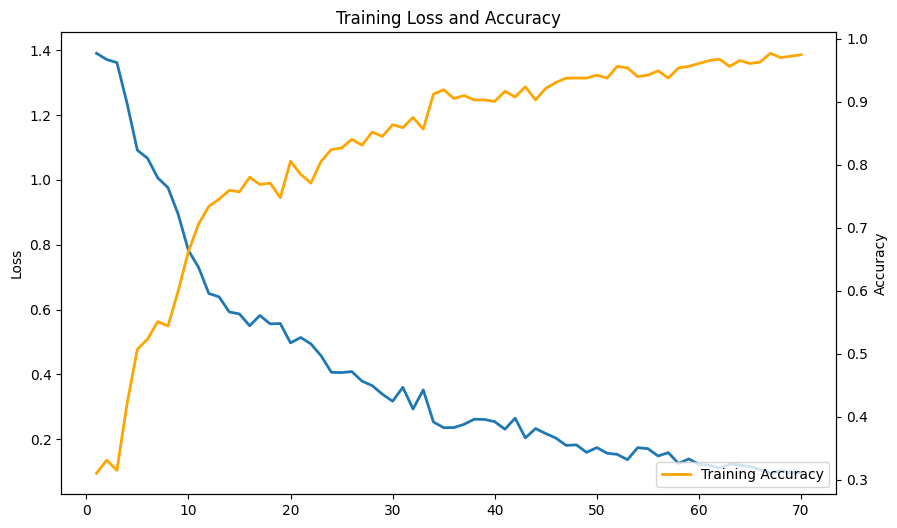

In [ ]:
import matplotlib.pyplot as plt

# 从训练历史对象中获取 loss 与 accuracy（model.fit(...) 的返回值）
history = model.history.history   # history 是一个 dict，包含 loss、categorical_accuracy 等

# 创建图像
plt.figure(figsize=(10, 6))

epochs = range(1, len(history['loss']) + 1)

# 左轴画 loss
plt.plot(epochs, history['loss'], label='Training Loss', linewidth=2)
plt.ylabel('Loss')

# 右轴画 accuracy
plt.twinx()  # 创建第二个 y 轴
plt.plot(epochs, history['categorical_accuracy'], color='orange', label='Training Accuracy', linewidth=2)
plt.ylabel('Accuracy')

# 设置标题与 x 轴
plt.title('Training Loss and Accuracy')
plt.xlabel('Epoch')

# 显示图例
plt.legend(loc='lower right')

plt.show()



In [30]:
# --- 1. 正常的模型保存 ---
VERSION = "V4.5_"

model.save(f'{VERSION}student_behavior_lstm.h5')
print(f"模型已成功保存为 {VERSION}student_behavior_lstm.h5")

模型已成功保存为 V4.5_student_behavior_lstm.h5


2/2 [==============================] - 1s 17ms/step


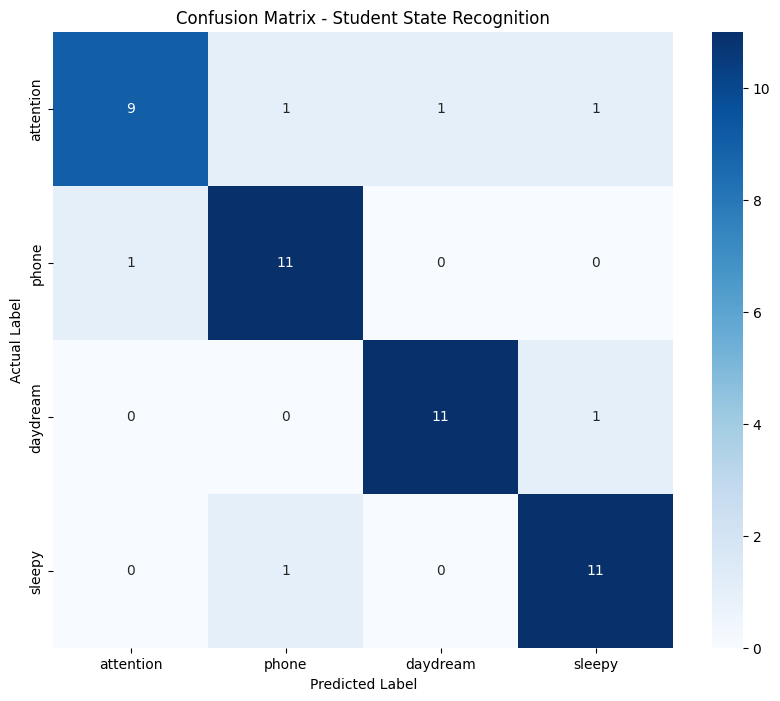

              precision    recall  f1-score   support

   attention       0.90      0.75      0.82        12
       phone       0.85      0.92      0.88        12
    daydream       0.92      0.92      0.92        12
      sleepy       0.85      0.92      0.88        12

    accuracy                           0.88        48
   macro avg       0.88      0.87      0.87        48
weighted avg       0.88      0.88      0.87        48



In [31]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 使用测试集进行预测
y_pred_res = model.predict(X_test)
y_pred = np.argmax(y_pred_res, axis=1)
y_true = np.argmax(y_test, axis=1)

# 2. 计算混淆矩阵
cm = confusion_matrix(y_true, y_pred)

# 3. 绘图
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=actions, yticklabels=actions)
plt.title('Confusion Matrix - Student State Recognition')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# 4. 打印详细报告（包含 Precision, Recall, F1-score）
# 核心修改：增加了 labels=range(len(actions))
# 这会强制报告匹配 4 个动作，没出现的动作会显示为 0
print(classification_report(y_true, y_pred, labels=range(len(actions)), target_names=actions))

In [32]:
# 查看测试集中实际存在的类别索引
present_classes = np.unique(y_true)
present_names = [actions[i] for i in present_classes]

print(f"actions 总共有: {len(actions)} 类")
print(f"测试集中实际存在的类有: {present_names}")

# 如果发现少了一个，建议去检查一下数据文件夹，看是不是那个动作的 .npy 文件太少了

actions 总共有: 4 类
测试集中实际存在的类有: ['attention', 'phone', 'daydream', 'sleepy']


In [ ]:
model.save_weights(f'{VERSION}only_weights.weights.h5')
print("✅ 纯权重文件已保存")